In [1]:
import sys
import os

import jax
import jax.numpy as np
import jax.random as jr
import equinox as eqx
from kneed import KneeLocator

# matplotlib configs
from matplotlib import pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

plt.style.use(['science',  'bright', 'no-latex'])
new_rcParams = {
    'image.cmap': 'inferno',
    'font.family': 'serif',
    'image.origin': 'lower',
    'figure.dpi': 300,
    'font.size': 8,
    'xtick.direction': 'out',
    'ytick.direction': 'out'
}
plt.rcParams.update(new_rcParams)

inferno = mpl.colormaps['inferno']
viridis = mpl.colormaps['viridis']
seismic = mpl.colormaps['seismic']
coolwarm = mpl.colormaps['coolwarm']

inferno.set_bad('k', 0.5)
viridis.set_bad('k', 0.5)
seismic.set_bad('k', 0.5)
coolwarm.set_bad('k', 0.5)

from frito.autoencoder.ae_utils import load_classes_from_file as lcf

In [17]:
master_key              = jr.key(0)
main_data_path          = '_data'
autoencoder_data_path   = os.path.join(main_data_path, 'autoencoder')
main_trained_model_path = os.path.join(autoencoder_data_path, 'trained_models')
main_svd_path           = os.path.join(autoencoder_data_path, 'svd')
training_data_path      = os.path.join(autoencoder_data_path, 'training_data')
emnist_path             = os.path.join(training_data_path, 'emnist.npz')
mnist_path              = os.path.join(training_data_path, 'mnist.npz')
ppd_51_path             = os.path.join(training_data_path, 'fake_intensity_PPDs_51x51.npz')

main_out_path           = '_output'
main_model_struct_path  = 'src/frito/autoencoder/model_structures'

ppd_51x51_data          = np.load(ppd_51_path)
test_51x51_data         = ppd_51x51_data['x_test']

In [3]:
model_key, master_key   = jr.split(master_key, 2)
model_type              = 'PPD'
i                           = 16
model_names             = [
                            "0_0", "0_2", "1_0", "1_2", 
                            "2_0", "2_1", "2_2", "3_0", 
                            "3_1", "3_2", "4_0", "4_1", 
                            "4_2", "7_0", "7_1", "7_2", 
                            "7_4", "7_5", "8_0", "8_2", 
                            "8_3", "8_4", "8_5", "8_6"
                            ]
model_name              = model_names[i]
model_struct_path       = os.path.join(main_model_struct_path, f'model_{model_name}.py')
trained_model_path      = os.path.join(main_trained_model_path, model_type, f'{model_name}_best.eqx')
autoencoder_classes     = lcf(model_struct_path)
autoencoder             = autoencoder_classes['autoencoder'](key=model_key)
base_autoencoder        = eqx.tree_deserialise_leaves(trained_model_path, autoencoder)

print(f"Model: {model_name}")
print(f'Model Struct: {model_struct_path}')
print(f'Trained Model Path: {trained_model_path}')
print(f'Autoencoder Classes: {autoencoder_classes}')

Model: 7_4
Model Struct: src/frito/autoencoder/model_structures/model_7_4.py
Trained Model Path: _data/autoencoder/trained_models/PPD/7_4_best.eqx
Autoencoder Classes: {'autoencoder': <class 'model_7_4.autoencoder'>, 'decoder': <class 'model_7_4.decoder'>, 'encoder': <class 'model_7_4.encoder'>}


In [4]:
print(base_autoencoder)

autoencoder(
  modules=[
    encoder(
      layers=[
        Conv2d(
          num_spatial_dims=2,
          weight=f32[32,1,7,7],
          bias=f32[32,1,1],
          in_channels=1,
          out_channels=32,
          kernel_size=(7, 7),
          stride=(1, 1),
          padding=((3, 3), (3, 3)),
          dilation=(1, 1),
          groups=1,
          use_bias=True,
          padding_mode='ZEROS'
        ),
        <PjitFunction of <function relu at 0x11a349c60>>,
        Conv2d(
          num_spatial_dims=2,
          weight=f32[32,32,7,7],
          bias=f32[32,1,1],
          in_channels=32,
          out_channels=32,
          kernel_size=(7, 7),
          stride=(1, 1),
          padding=((3, 3), (3, 3)),
          dilation=(1, 1),
          groups=1,
          use_bias=True,
          padding_mode='ZEROS'
        ),
        <PjitFunction of <function relu at 0x11a349c60>>,
        Conv2d(
          num_spatial_dims=2,
          weight=f32[32,32,7,7],
          bias=f32[32,1,

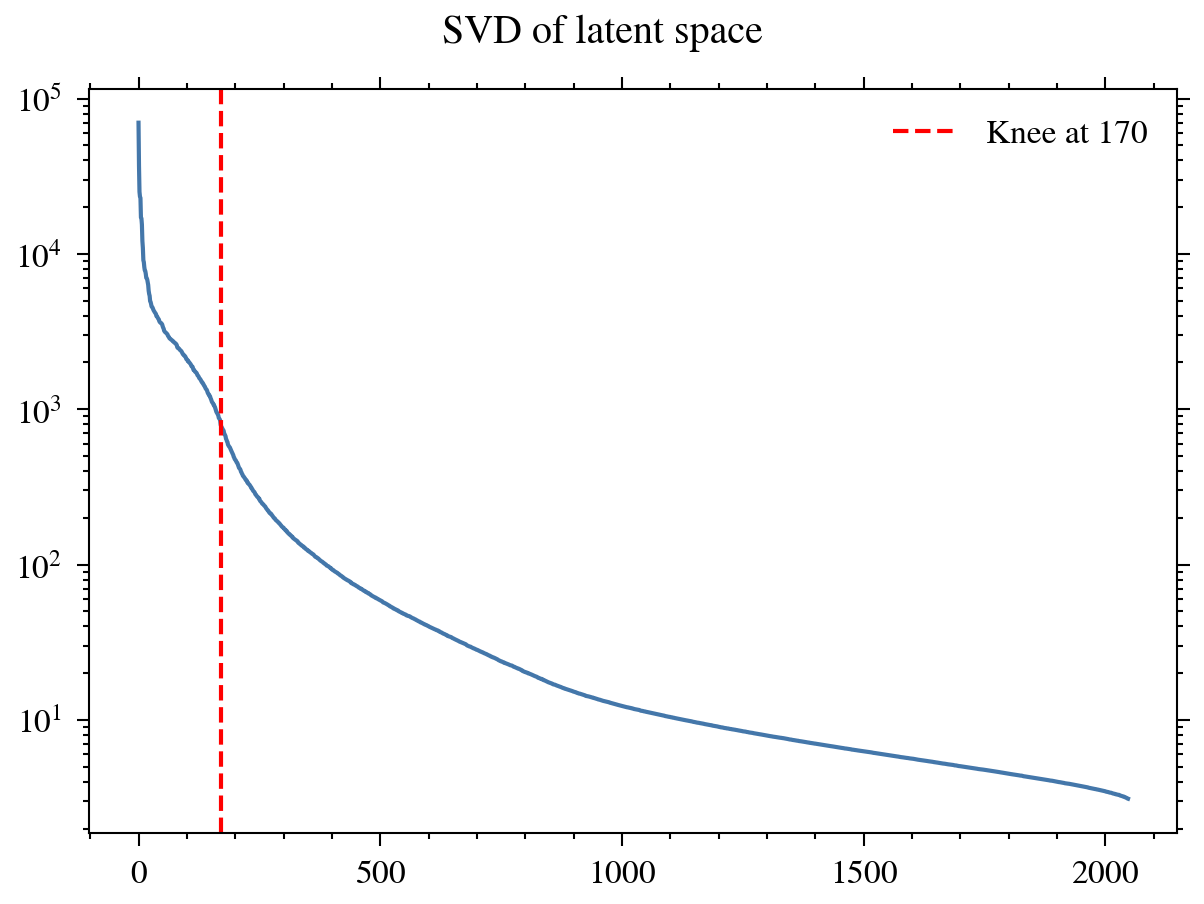

SVD Path: _data/autoencoder/svd/PPD_model_7_4_svd.npz
Knee at 170


In [5]:
svd_path    = os.path.join(main_svd_path, f'{model_type}_model_{model_name}_svd.npz')
svd         = np.load(svd_path)

k1          = KneeLocator(np.arange(len(svd['s'])), svd['s'], curve='convex', direction='decreasing', online=True)

fig, ax     = plt.subplots(figsize=(4,3), layout='constrained')
fig.suptitle('SVD of latent space')
ax.plot(svd['s'], marker=',')
ax.axvline(k1.knee, color='r', linestyle='--', label=f'Knee at {k1.knee}')
ax.legend()
ax.set_yscale('log')
plt.show()

print(f'SVD Path: {svd_path}')
print(f'Knee at {k1.knee}')

In [15]:
tmp_keys                    = jr.split(master_key, 3)
suture_keys                = tmp_keys[:2]
master_key                  = tmp_keys[2]

new_encode_in               = base_autoencoder.modules[0].layers[-1].in_features
new_encode_out              = int(k1.knee)
new_encode_latent_weights   = base_autoencoder.modules[0].layers[-1].weight[:new_encode_out, :]
new_encode_latent_biases    = base_autoencoder.modules[0].layers[-1].bias[:new_encode_out]
new_encode_linear           = eqx.nn.Linear(in_features=new_encode_in,
                                           out_features=new_encode_out, key=suture_keys[0])
trained_new_encode_linear   = eqx.tree_at(lambda l: l.weight, new_encode_linear,
                                         new_encode_latent_weights)
trained_new_encode_linear   = eqx.tree_at(lambda l: l.bias, trained_new_encode_linear,
                                         new_encode_latent_biases)
sutured_ae_struct           = eqx.tree_at(lambda m: m.modules[0].layers[-1],
                                         base_autoencoder, trained_new_encode_linear)


def embed(X, knee, m, s, v):
    return (X - m[:knee]) @ v[:knee, :knee].T / np.sqrt(s[:knee] ** 2 / knee)

embed_layer   = eqx.nn.Lambda(
    lambda z: embed(z, int(k1.knee), svd['mean'], svd['s'], svd['v'])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers, sutured_ae_struct,
    sutured_ae_struct.modules[0].layers + [embed_layer]
)

def unembed(embedded, knee, m, s, v):
    return ((embedded) * np.sqrt(s[:knee] ** 2 / knee)) @ v[:knee, :knee] + m[:knee]

unembed_layer = eqx.nn.Lambda(
    lambda z: unembed(z, int(k1.knee), svd['mean'], svd['s'], svd['v'])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers, sutured_ae_struct,
    [unembed_layer] + sutured_ae_struct.modules[1].layers
)

new_decode_out              = sutured_ae_struct.modules[1].layers[2].out_features
new_decode_in               = int(k1.knee)
new_decode_latent_weights   = sutured_ae_struct.modules[1].layers[2].weight[:, :new_decode_in]
new_decode_latent_biases    = sutured_ae_struct.modules[1].layers[2].bias
new_decode_linear           = eqx.nn.Linear(in_features=new_decode_in,
                                             out_features=new_decode_out, key=suture_keys[1])
trained_new_decode_linear   = eqx.tree_at(lambda l: l.weight, new_decode_linear,
                                           new_decode_latent_weights)
trained_new_decode_linear   = eqx.tree_at(lambda l: l.bias, trained_new_decode_linear,
                                           new_decode_latent_biases)
sutured_ae_struct           = eqx.tree_at(lambda m: m.modules[1].layers[2],
                                           sutured_ae_struct, trained_new_decode_linear)

sutured_model_path          = os.path.join(main_trained_model_path, model_type, f'{model_name}_Rbest.eqx')
sutured_ae = eqx.tree_deserialise_leaves(sutured_model_path, sutured_ae_struct)
print(f'Suture Model Path: {sutured_ae_struct}')
print(sutured_ae)

Suture Model Path: autoencoder(
  modules=[
    encoder(
      layers=[
        Conv2d(
          num_spatial_dims=2,
          weight=f32[32,1,7,7],
          bias=f32[32,1,1],
          in_channels=1,
          out_channels=32,
          kernel_size=(7, 7),
          stride=(1, 1),
          padding=((3, 3), (3, 3)),
          dilation=(1, 1),
          groups=1,
          use_bias=True,
          padding_mode='ZEROS'
        ),
        <PjitFunction of <function relu at 0x11a349c60>>,
        Conv2d(
          num_spatial_dims=2,
          weight=f32[32,32,7,7],
          bias=f32[32,1,1],
          in_channels=32,
          out_channels=32,
          kernel_size=(7, 7),
          stride=(1, 1),
          padding=((3, 3), (3, 3)),
          dilation=(1, 1),
          groups=1,
          use_bias=True,
          padding_mode='ZEROS'
        ),
        <PjitFunction of <function relu at 0x11a349c60>>,
        Conv2d(
          num_spatial_dims=2,
          weight=f32[32,32,7,7],
     

In [16]:
def sum2unity(X):
    return X / np.sum(X, axis=(1, 2), keepdims=True)

sum2unity_layer     = eqx.nn.Lambda(lambda z: sum2unity(z))
norm_sutured_ae     = eqx.tree_at(
        lambda m: m.modules[1].layers,
        sutured_ae,
        sutured_ae.modules[1].layers + [sum2unity_layer]
)

encoder, decoder    = norm_sutured_ae.modules

Text(0.5, 1.0, 'Autoencoded Image')

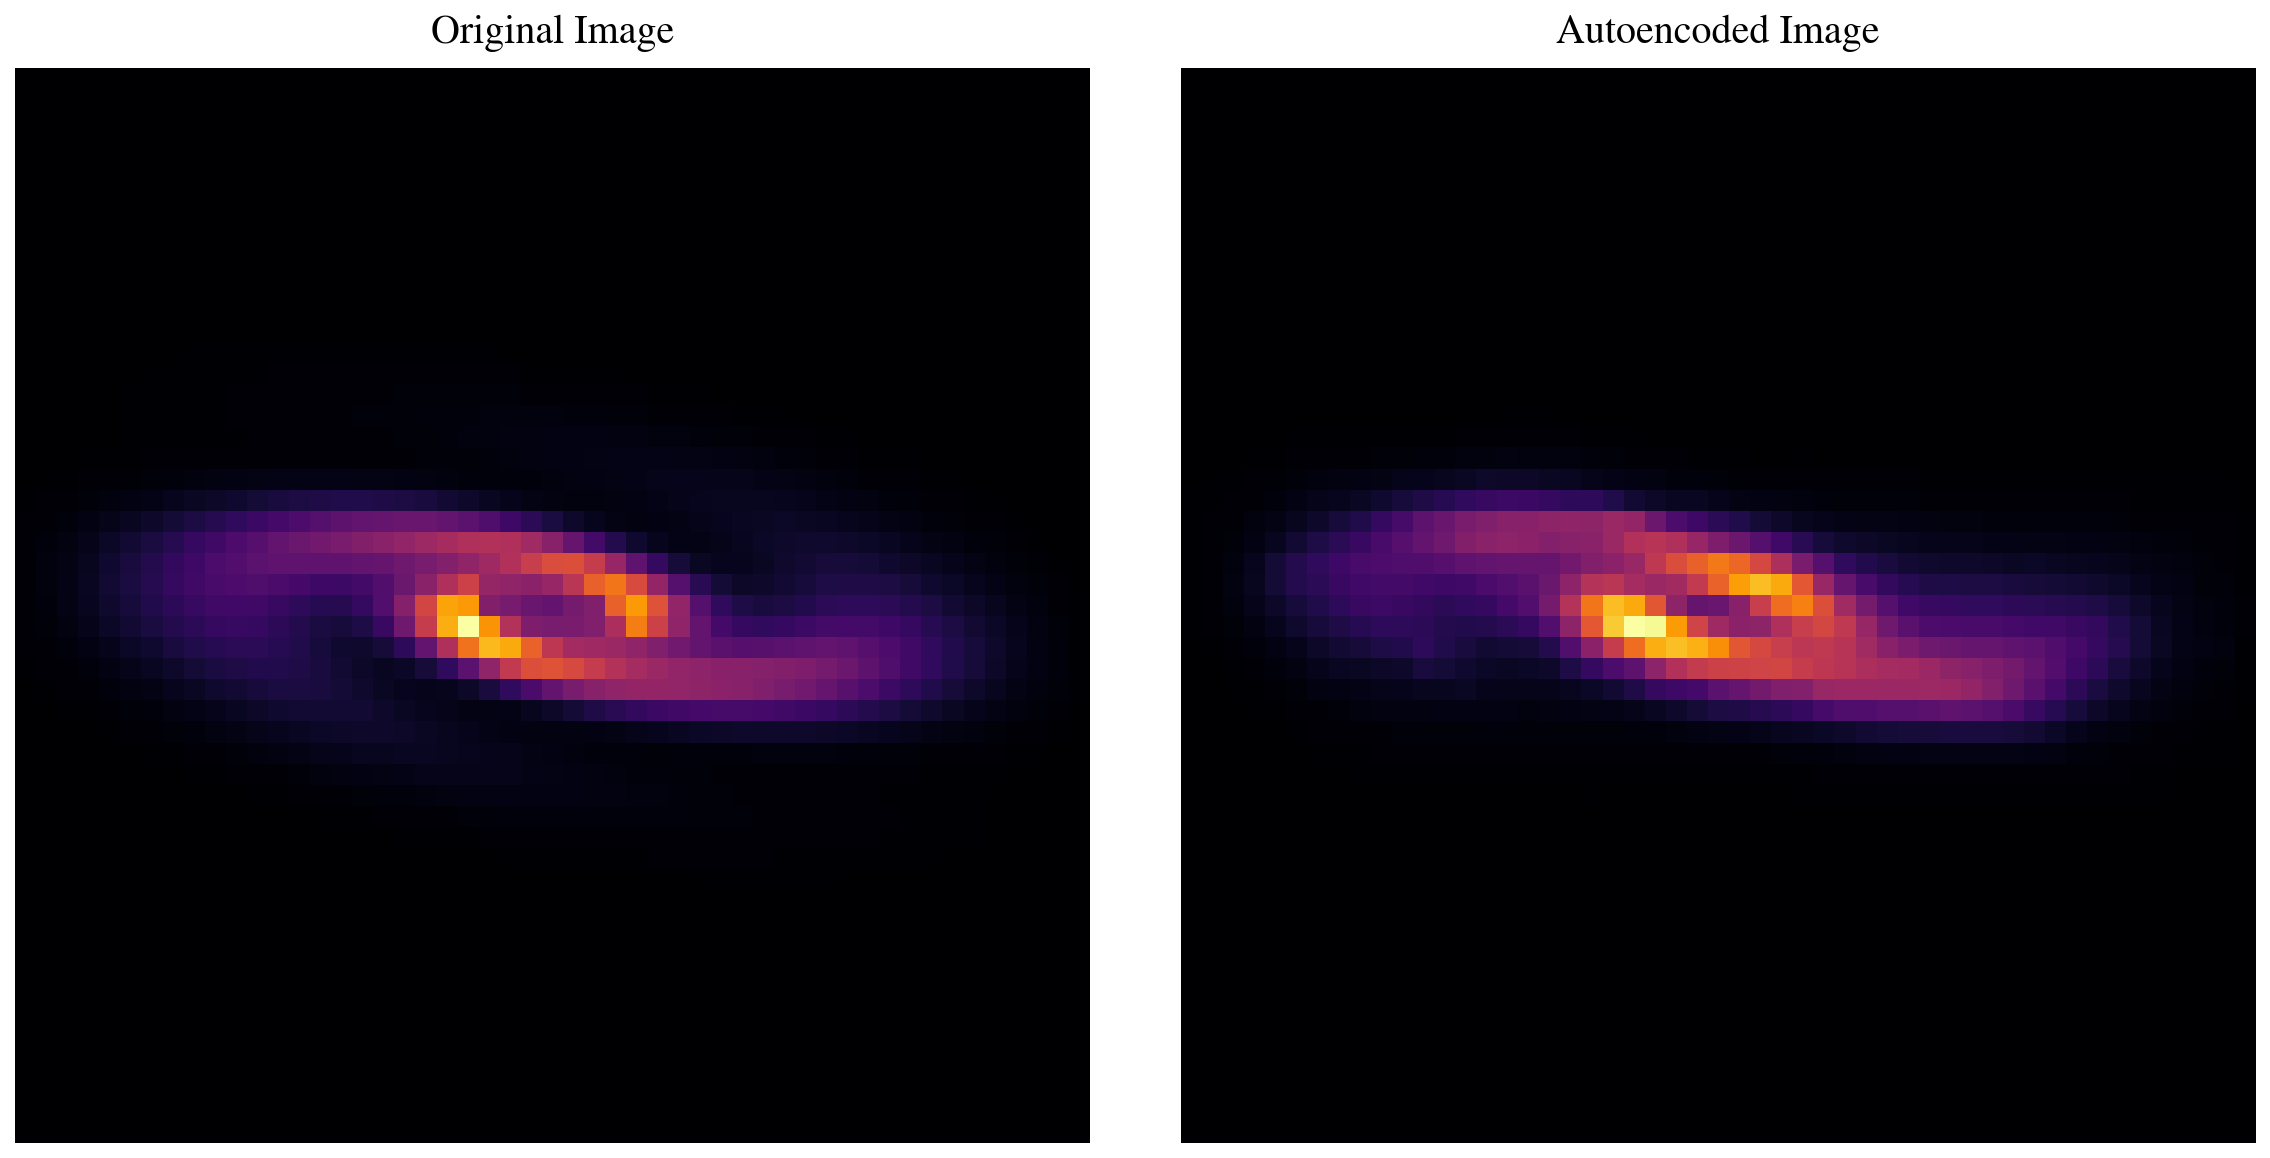

In [28]:
ppd_idx = 54
ppd_img = test_51x51_data[ppd_idx]

fig, [ax1, ax2] = plt.subplots(1,2, figsize = (8,4),layout='tight')
ax1.imshow(ppd_img)
ax1.set_axis_off()
ax1.set_title('Original Image')
ax2.imshow(decoder(encoder(ppd_img.reshape(1,51,51)))[0])
ax2.set_axis_off()
ax2.set_title('Autoencoded Image')